In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score

In [2]:
df=pd.read_csv('Teen_Mental_Health_Dataset.csv')

In [3]:
print("We have {} Rows and {} Columns in our data".format(df.shape[0], df.shape[1]))

We have 1200 Rows and 13 Columns in our data


In [4]:
df.head(5)

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [5]:
df.columns

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


In [7]:
df.describe(include='all')

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200,1200.000000,1200,1200.000000,1200.000000,1200.000000,1200.000000,1200,1200.000000,1200.000000,1200.000000,1200.000000
unique,NaN,2,NaN,3,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN
top,NaN,male,NaN,Instagram,NaN,NaN,NaN,NaN,medium,NaN,NaN,NaN,NaN
freq,NaN,615,NaN,411,NaN,NaN,NaN,NaN,416,NaN,NaN,NaN,NaN
mean,15.928333,NaN,4.536667,NaN,6.449417,1.740333,2.990383,1.014500,NaN,5.445833,5.636667,5.565000,0.025833
std,2.021947,NaN,2.029599,NaN,1.442677,0.716660,0.576758,0.582185,NaN,2.903290,2.859453,2.830627,0.158704
min,13.000000,NaN,1.000000,NaN,4.000000,0.500000,2.000000,0.000000,NaN,1.000000,1.000000,1.000000,0.000000
25%,14.000000,NaN,2.800000,NaN,5.200000,1.100000,2.500000,0.500000,NaN,3.000000,3.000000,3.000000,0.000000
50%,16.000000,NaN,4.500000,NaN,6.500000,1.800000,2.990000,1.000000,NaN,5.000000,6.000000,6.000000,0.000000
75%,18.000000,NaN,6.300000,NaN,7.600000,2.400000,3.480000,1.500000,NaN,8.000000,8.000000,8.000000,0.000000


In [8]:
#Categorical columns
df.describe(include='object').T

,count,unique,top,freq
gender,1200,2,male,615
platform_usage,1200,3,Instagram,411
social_interaction_level,1200,3,medium,416


In [9]:
# Checking the null values
df.isna().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

In [10]:
# checking for duplicate value
df.duplicated().sum()

0

In [11]:
# Univariate analysis

In [12]:
numerical_col=df.select_dtypes(include=[np.number]).columns.tolist()
categorical_col=df.select_dtypes(include='object').columns.tolist()

print(numerical_col)
print(categorical_col)

['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'stress_level', 'anxiety_level', 'addiction_level', 'depression_label']
['gender', 'platform_usage', 'social_interaction_level']


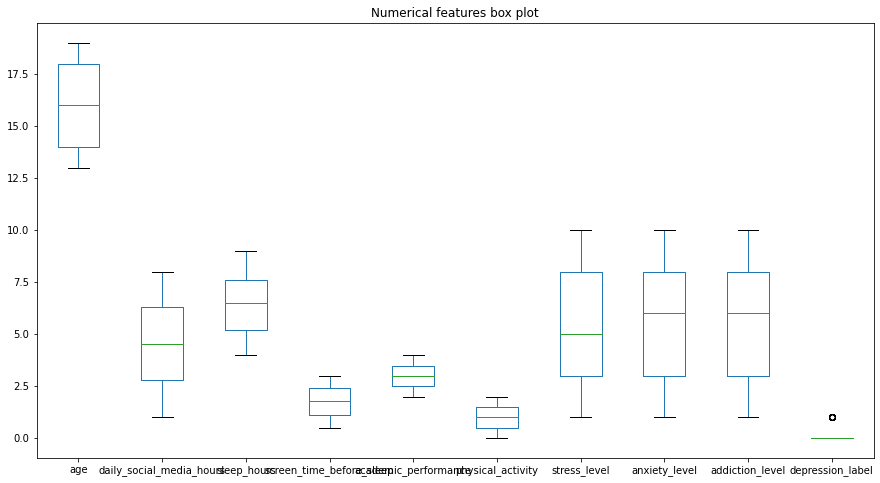

In [13]:
# check for the outliers
num_cols=df.select_dtypes(include='number').columns
df[num_cols].plot(kind='box',figsize=(15,8))
plt.title('Numerical features box plot')
plt.show()

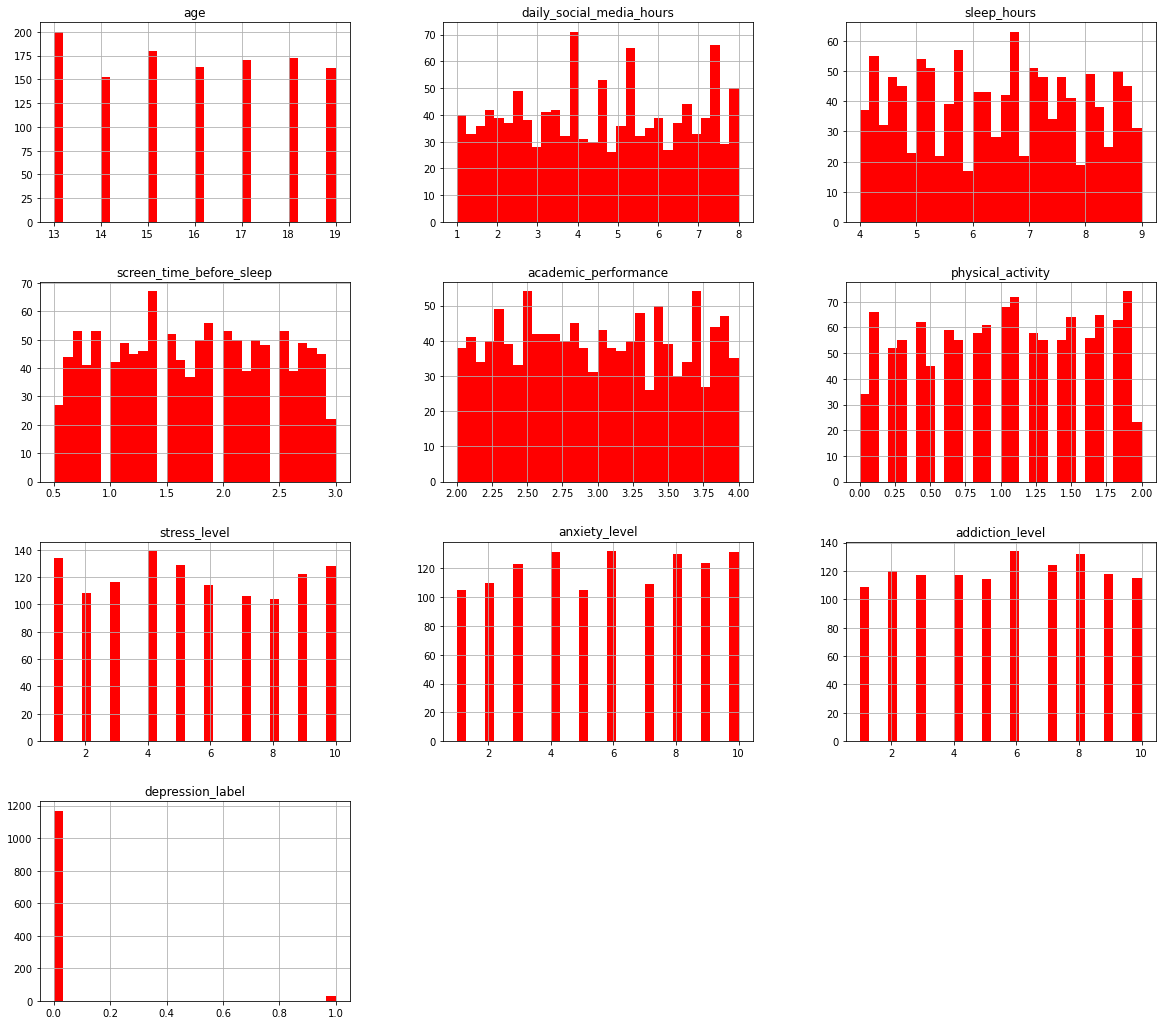

In [14]:
df.hist(figsize=(20,18),bins=30,color='red')
plt.show()

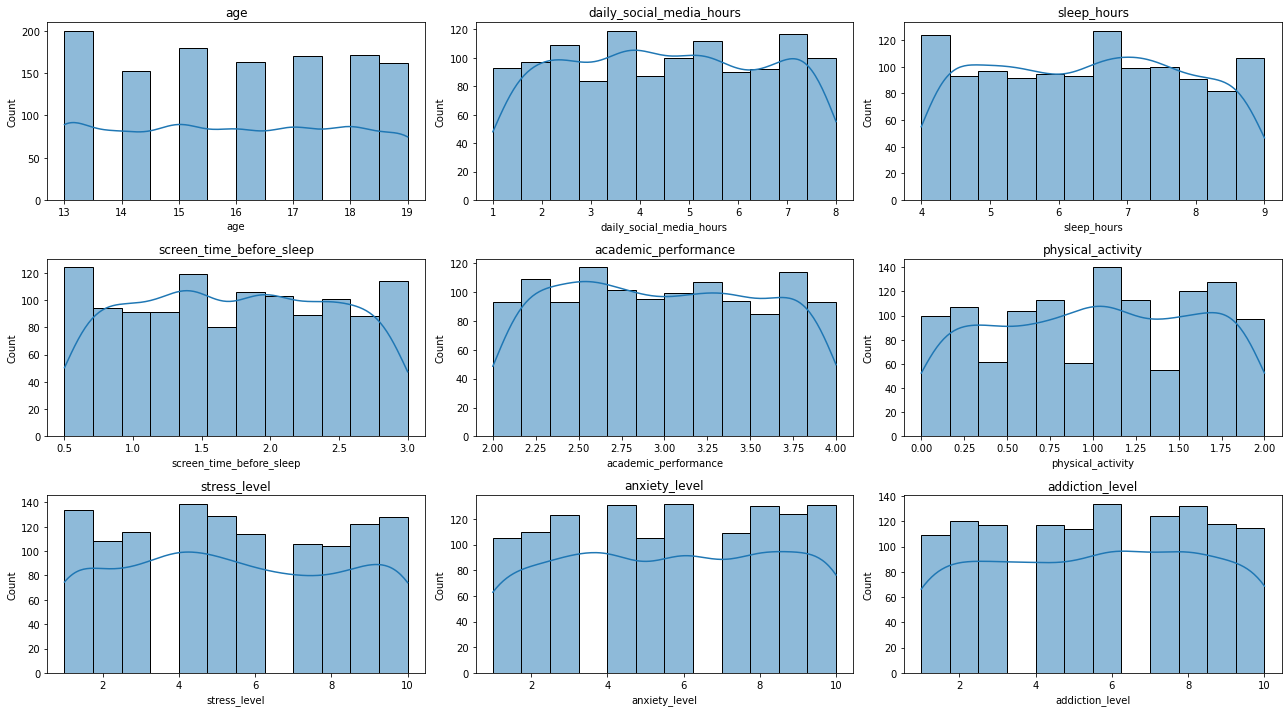

In [15]:
numeric_cols = [col for col in df.select_dtypes(include='number').columns
                if col != 'depression_label']

plt.figure(figsize=(18,10))

for i in range(len(numeric_cols)):
    plt.subplot(3,3,i+1)
    sns.histplot(df[numeric_cols[i]], kde=True)
    plt.title(numeric_cols[i])

plt.tight_layout()
plt.show()

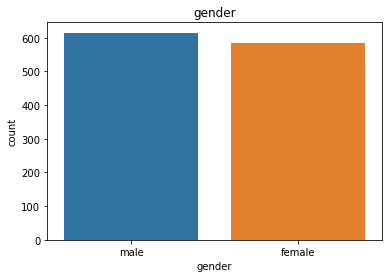

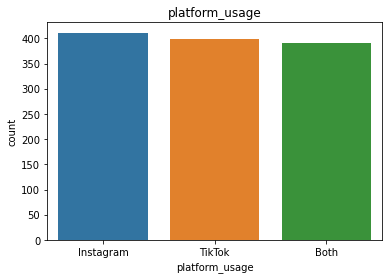

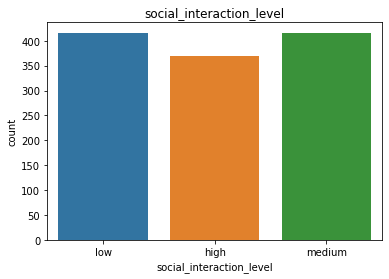

In [16]:
categorical_cols=df.select_dtypes(include='object').columns

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df,x=col)
    plt.title(col)
    plt.show()

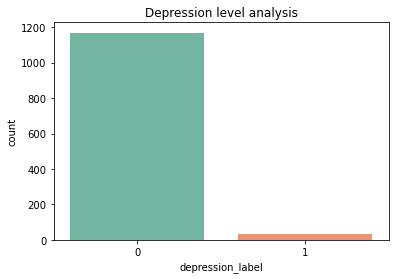

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(x='depression_label',data=df,palette='Set2')
plt.title('Depression level analysis')
plt.show()

In [18]:
# Bivariate analysis

<AxesSubplot:xlabel='depression_label', ylabel='count'>

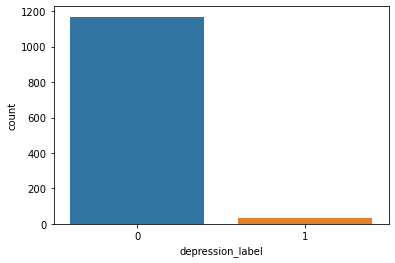

In [19]:
sns.countplot(data=df,x='depression_label')

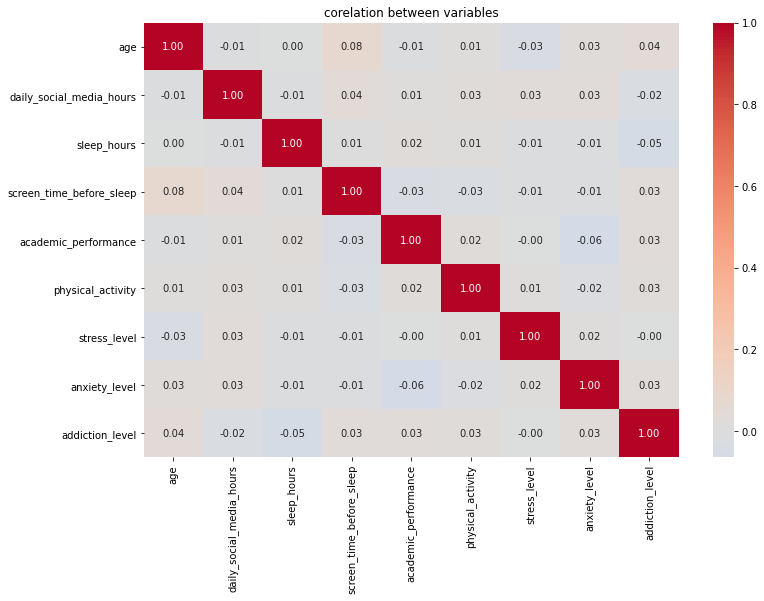

In [20]:
# corelation matrix
plt.figure(figsize=(12,8))
corr=df[numeric_cols].corr()
sns.heatmap(corr,annot=True,fmt='.2f',cmap='coolwarm',center=0)
plt.title('corelation between variables')
plt.show()

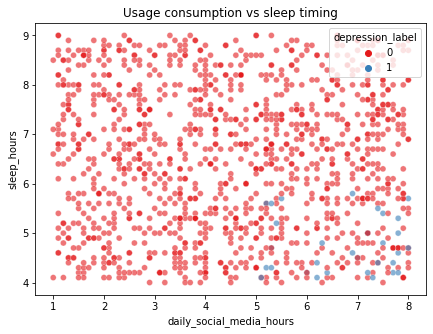

In [21]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='daily_social_media_hours',y='sleep_hours',hue='depression_label',data=df,palette='Set1',alpha=0.6)
plt.title('Usage consumption vs sleep timing')
plt.show()

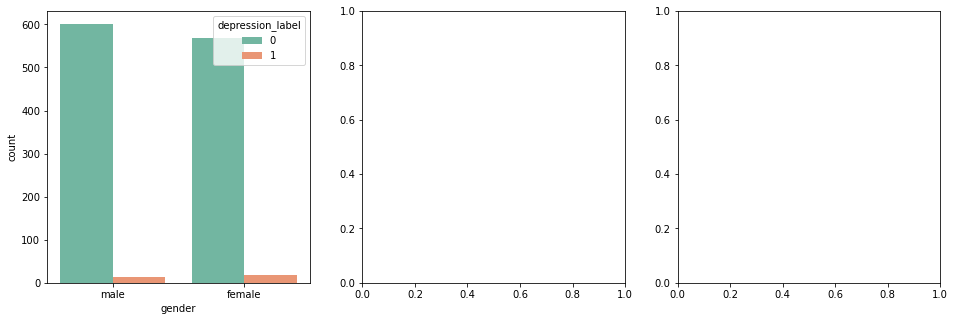

In [22]:
fig,axes=plt.subplots(1,3,figsize=(16,5))
for i,col in enumerate(categorical_cols):
    sns.countplot(x=col,hue='depression_label',data=df,ax=axes[i],palette='Set2')
    plt.show()

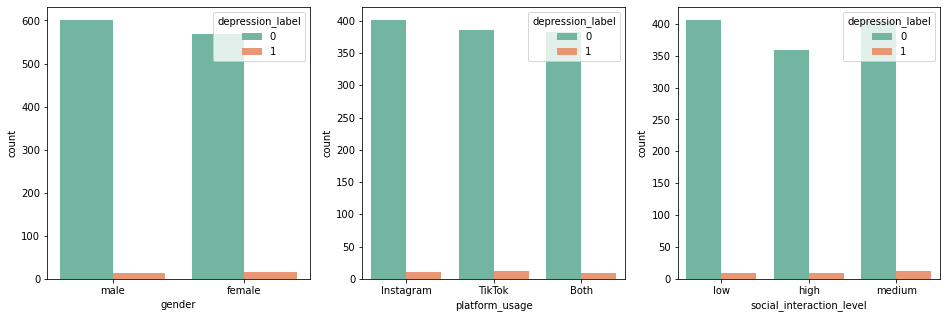

In [23]:
 fig, axes = plt.subplots(1,3, figsize=(16,5))
for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, hue='depression_label', data=df, ax=axes[i], palette='Set2')
plt.show()

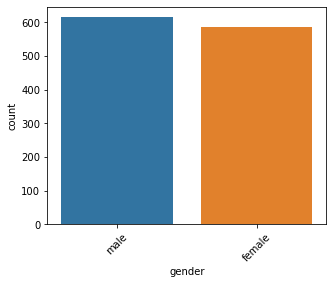

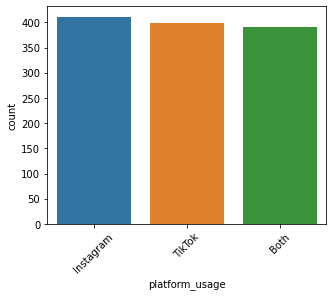

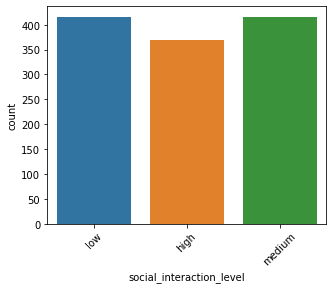

In [24]:
categorical_col=df.select_dtypes(include='object').columns

for col in categorical_col:
    plt.figure(figsize=(5,4))
    sns.countplot(data=df,x=col)
    plt.xticks(rotation=45)
    plt.show()

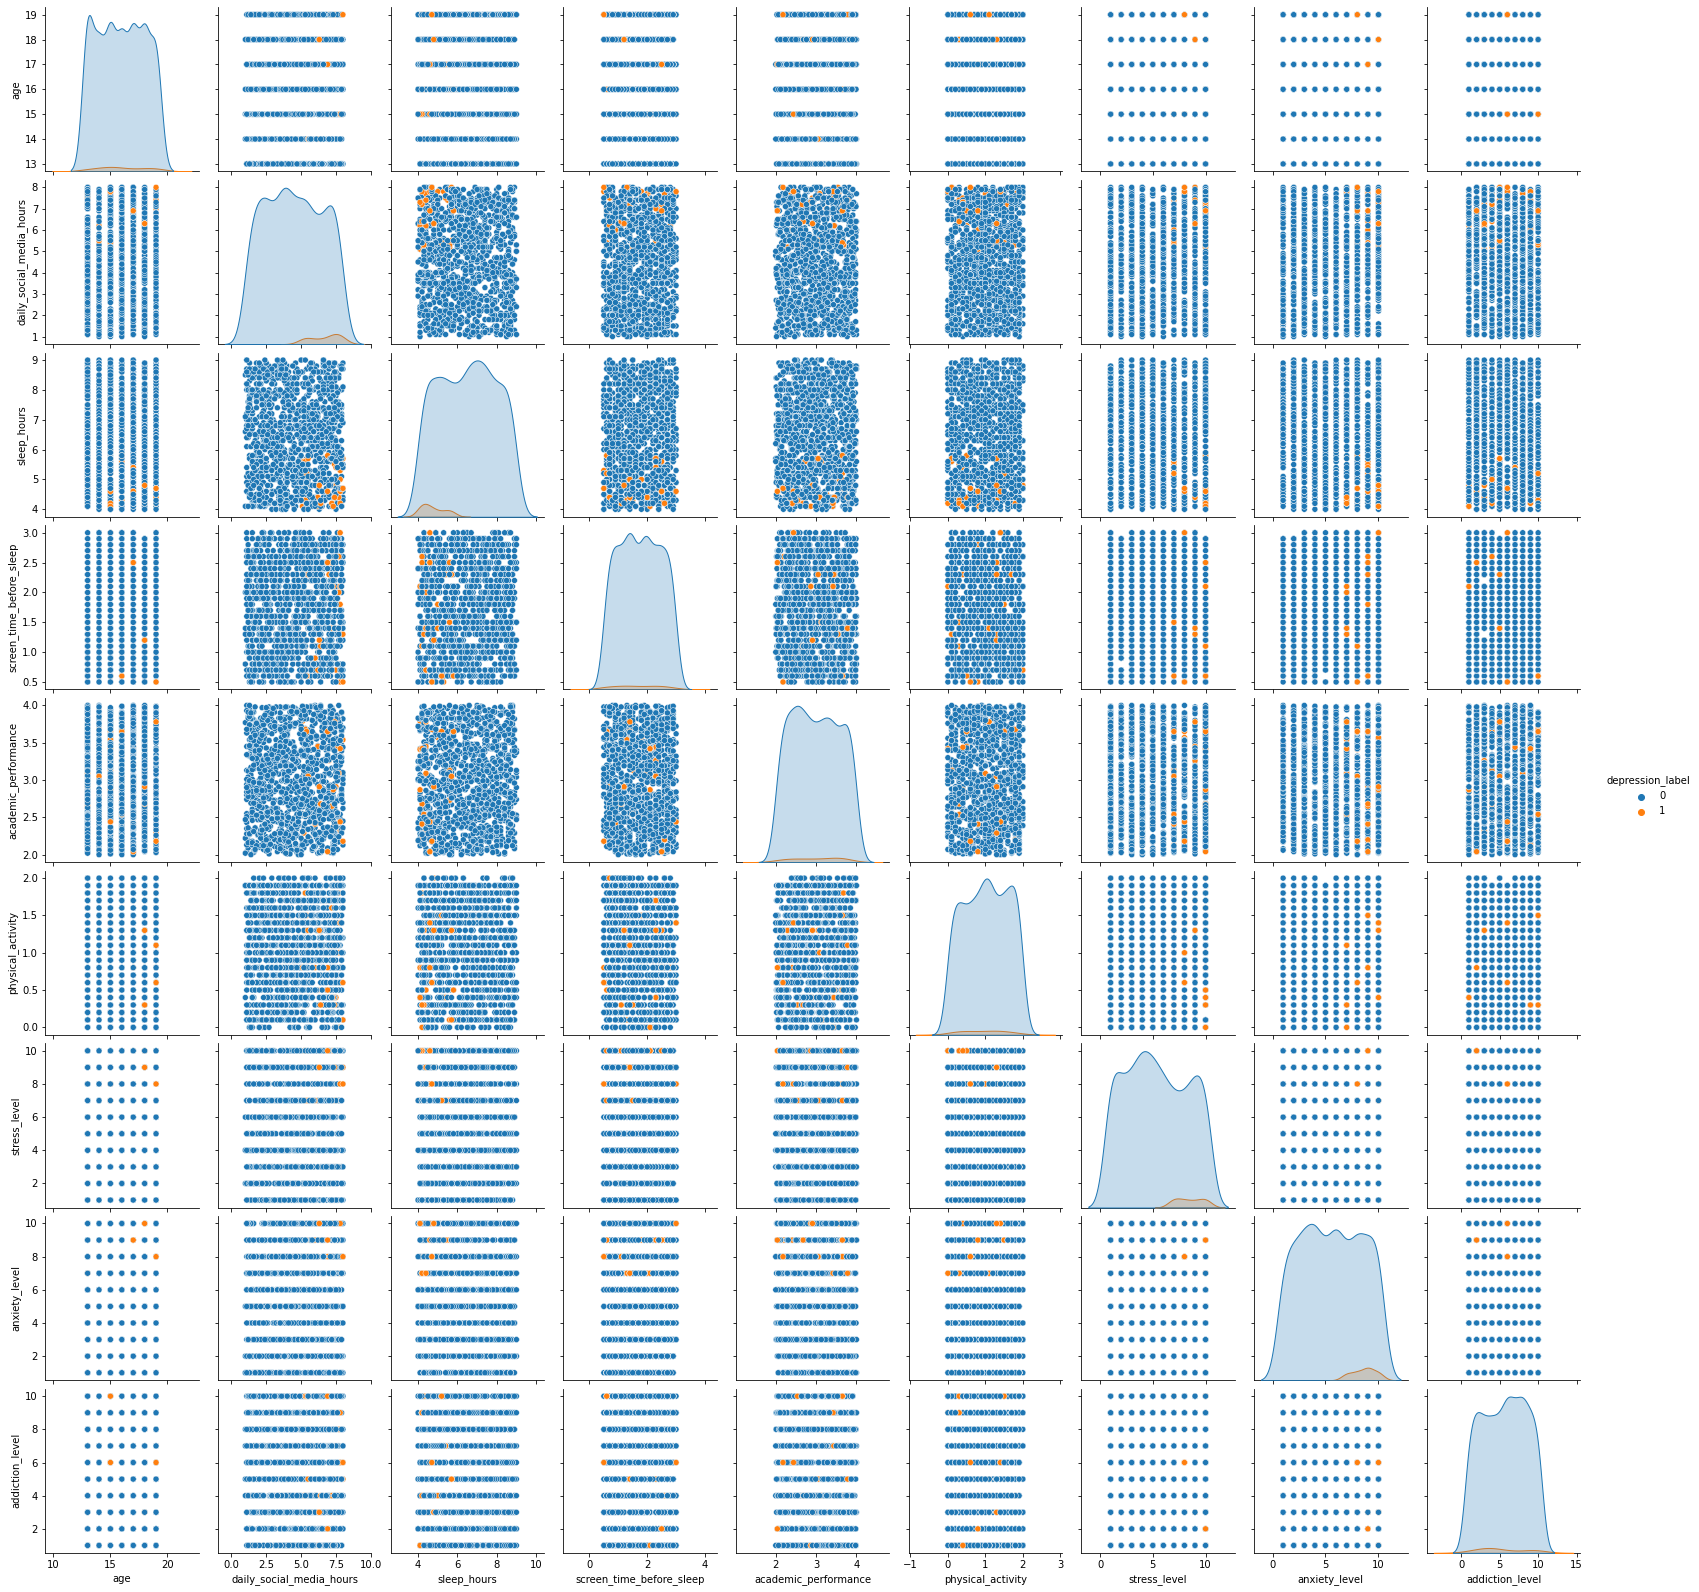

In [25]:
sns.pairplot(df,hue='depression_label')

In [26]:
# Feature engineering

In [27]:
# for categorical variables
encoder=LabelEncoder()

for col in categorical_col:
    df[col]=encoder.fit_transform(df[col])

In [28]:
# feature scaling
X=df.drop('depression_label',axis=1)
y=df['depression_label']

In [29]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [30]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

print("Train Shape:",X_train.shape,"Test Shape:",X_test.shape)

Train Shape: (960, 12) Test Shape: (240, 12)


In [31]:
lr = LogisticRegression()


lr.fit(X_train, y_train)


y_pred = lr.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred))

# Score
print(classification_report(y_test, y_pred))

Accuracy: 0.9875
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       234
           1       1.00      0.50      0.67         6

    accuracy                           0.99       240
   macro avg       0.99      0.75      0.83       240
weighted avg       0.99      0.99      0.99       240



In [32]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)


y_pred = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

# Score
print(classification_report(y_test, y_pred))

Accuracy: 0.9916666666666667
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       234
           1       0.83      0.83      0.83         6

    accuracy                           0.99       240
   macro avg       0.91      0.91      0.91       240
weighted avg       0.99      0.99      0.99       240



In [33]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)


y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

# Score
print(classification_report(y_test, y_pred))

Accuracy: 0.9791666666666666
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       234
           1       1.00      0.17      0.29         6

    accuracy                           0.98       240
   macro avg       0.99      0.58      0.64       240
weighted avg       0.98      0.98      0.97       240



In [34]:
results = {
    "Logistic Regression": accuracy_score(y_test, lr.predict(X_test)),
    "Decision Tree": accuracy_score(y_test, dt.predict(X_test)),
    "Random Forest": accuracy_score(y_test, rf.predict(X_test)),
}

results

{'Logistic Regression': 0.9875,
 'Decision Tree': 0.9916666666666667,
 'Random Forest': 0.9791666666666666}

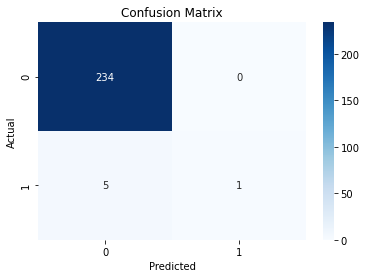

In [35]:
# Confusion matrix
y_pred = rf.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

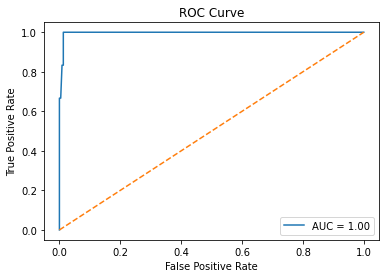

In [36]:
y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
# Roc/Auc Score
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

# Insights

The dataset contains 1,200 records and 13 features with no missing values or duplicate records, 
making it suitable for machine learning analysis.
 
Teenagers spend an average of 4.5 hours per day on social media.
    
The scatter plot indicates that higher social media usage is generally associated with lower sleep duration, suggesting a potential negative impact on sleep habits.

 Most teenagers sleep between 5 and 8 hours.
    
Lower sleep duration appears to be associated with higher depression risk. 

The dataset is highly imbalanced, with far fewer depressed cases than non-depressed cases. 
    
This explains why overall accuracy is very high while the number of positive (depressed) cases is small.


The confusion matrix indicates that most students were classified correctly. 
    
The ROC curve demonstrates strong classification performance, indicating good separation
between depressed and non-depressed classes

